**Task 1**  
NAIP feature extraction:
* visible appearance of shrubs
* texture
* color differences - complete via gradients
* local boundaries
* surrounding land-cover context
* NIR-based vegetation signal

Bands to process:
* RGB
* NIR 

Derived features
* NDVI
* local variance
* entropy
* edge density
* local binary patterns
* GLCM-style texture summaries
* gradient magnitude

**Task 2**  
Recalculate above features, but with different kernel sizes (e.g. 5x5, 7x7, etc.)

**Plan 1**  
Extract all features noting that the overhead makes it possible for trees to cover shrubs, but this itself should be a useful feature.  




In [42]:
# TODO - read in NAIP file and then you can perform all image processing
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from typing import List
from pathlib import Path

naip_fp = Path("naip_sample_data") / "m_3912038_ne_10_060_20220720.tif"

rgb_channels = [1,2,3]
nir_channel = [4]
with rasterio.open(naip_fp) as src:
    print(type(src))
    # rgb = get_naip_channels(src, rgb_channels)
    # plt.imshow(rgb)
    # plt.axis("off")
    # plt.show()

    # nir = get_naip_channels(src, nir_channel)
    # plt.imshow(nir)
    # plt.axis("off")
    # plt.show()

<class 'rasterio.io.DatasetReader'>


In [43]:
import os

naip_save_dir = Path("naip_channel_processed")
if not os.path.exists(naip_save_dir):
    print("Created .../features/naip_channel_processed directory")
    os.mkdir(naip_save_dir, exist_ok=False)

In [51]:
def extract_color_channels(src: rasterio.io.DatasetReader, channels: List):
    """
    Returns rgb color channels from NAIP input image
    
    Args:
        src - 2d array from result of `with rasterio.open(naip_fp) as src: ...`
    """
    scale = 1
    preview = src.read(
        indexes=channels, 
        out_shape=(len(channels), src.height // scale, src.width // scale),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype(np.float32)

    channel = np.transpose(preview, (1,2,0))
    clamp = np.clip(channel / (np.nanmax(channel) + 1e-12), 0, 1)

    return clamp

In [56]:
def get_all_bands(src: rasterio.io.DatasetReader):
    channels = list(np.arange(1, src.count+1))

    bands = list()
    all_bands = extract_color_channels(src, channels)
    for band in range(src.count):
        bands.append(all_bands[:,:,band])

    return bands

In [57]:
def get_naip_info(src):
    info = dict()

    info["dims"] = (src.width, src.height)
    info["crs"] = src.crs
    info["num_bands"] = src.count
    info["band_dtypes"] = src.dtypes
    info["bounding_box"] = src.bounds
    info["res"] = src.res

    return info

In [58]:
fname = "m_3912038_ne_10_060_20220720.tif"
naip_fp = Path("naip_sample_data")
naip_save_dir = Path("naip_channel_processed")

with rasterio.open(naip_fp / fname) as src:
    bands = get_all_bands(src)

    for band in bands:
        print(band.shape)
    # fname = fname.split(".tif")[0]
    # np.save(naip_save_dir / fname, bands)

(12500, 9980)
(12500, 9980)
(12500, 9980)
(12500, 9980)


In [60]:
band.shape

(12500, 9980)

In [62]:
src

<closed DatasetReader name='naip_sample_data\m_3912038_ne_10_060_20220720.tif' mode='r'>

In [ ]:
def get_gradient_kernels():
    lap_adjacent = np.array([
        [0,1,0],
        [1,-4,1],
        [0,1,0] 
    ])

    lap_surround = np.array([
        [1,1,1],
        [1,-8,1],
        [1,1,1]
    ])

    sobel_x = np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ])

    sobel_y = np.array([
        [-1,-2,-1],
        [0,0,0],
        [1,2,1],
    ])

    scharr_x = np.array([
        [-3,0,3],
        [-10,0,10],
        [-3,0,3]
    ])

    scharr_y = np.array([
        [-3,-10,-3],
        [0,0,0],
        [3,10,3],
    ])

    prewitt_x = np.array([
        [-1,0,1],
        [-1,0,1],
        [-1,0,1]
    ])

    prewitt_y = np.array([
        [-1,-1,-1],
        [0,0,0],
        [1,1,1]
    ])

    roberts_positive = np.array([
        [1,0],
        [0,-1]
    ])

    roberts_negative = np.array([
        [0,1],
        [-1,0]
    ])

    gradient_kernels = [
        lap_adjacent,
        lap_surround,
        sobel_x,
        sobel_y,
        scharr_x,
        scharr_y,
        prewitt_x,
        prewitt_y,
        roberts_positive,
        roberts_negative
    ]

    return gradient_kernels



In [ ]:
from scipy.signal import convolve2d
from skimage import feature
from scipy.ndimage import morphological_gradient

def get_color_diff(band, kernel):
    """
    Retrieves the color difference for a single band by applying the specified kernel.

    Args:
        band - 2d array of pixels
        kernel - kernel for convolution
    """
    # same fill is not an option
    color_diff = convolve2d(band, kernel, boundary="fill") 
    color_diff = color_diff[1:-1, 1:-1].astype(int)

    # plotting color diff is not useful, but patterns can be learned from it
    return color_diff


with rasterio.open(naip_fp / fname) as src:
    bands = get_all_bands(src)

    output_feats = list([] for _ in range(src.count))

    gradient_kernels = get_gradient_kernels()
    std_range = list(range(1,6)) # higher stds don't have visually noticeable boundaries
    min_kernel_radius, max_kernel_radius = 2, 5 # distance from center to border, not including the center cell.


    # individual bands can be effectively be treated as grayscale
    for i, band in enumerate(bands[:1]):
        continue
        # neighbor differences
        for kernel in gradient_kernels:
            adj_diff = get_color_diff(band, kernel)
            output_feats[i].append(adj_diff)
        
        # boundary detection
        for std in std_range:
            boundaries = feature.canny(band.astype(float), sigma=std)
            output_feats[i].append(boundaries)

        for side_length in range(1+min_kernel_radius, 1+max_kernel_radius*2, 2):
            morph_grad = morphological_gradient(band, size=(side_length, side_length))
            output_feats[i].append(morph_grad)




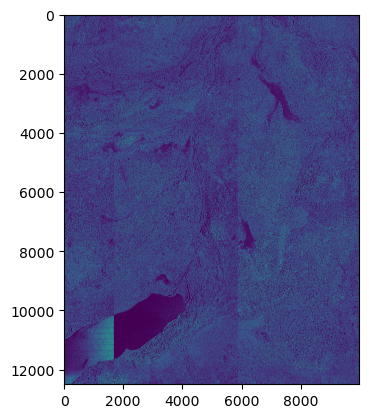

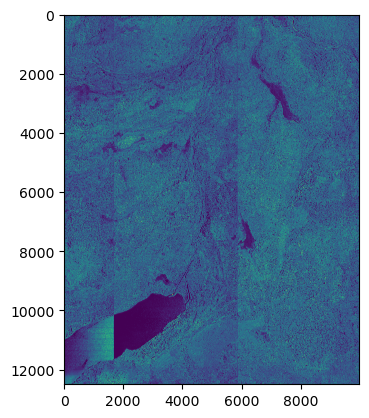

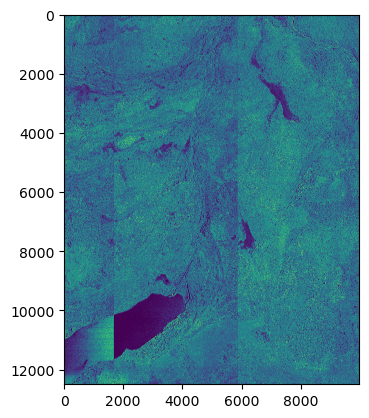

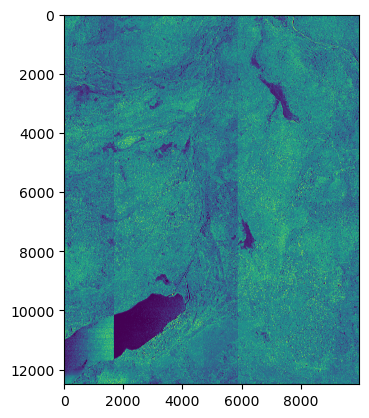

In [ ]:
import numpy as np

min_kernel_radius, max_kernel_radius = 1, 5
for side_length in range(1+2*min_kernel_radius, 1+max_kernel_radius*2, 2):
    print()
    morph_grad = morphological_gradient(band, size=(side_length, side_length))
    output_feats[i].append(morph_grad)

In [87]:
res = convolve2d(band, lap_adjacent, boundary="fill")
res.shape

(12502, 9982)

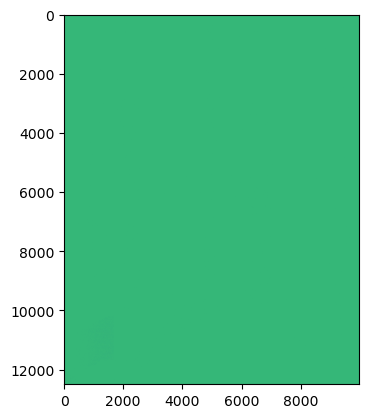

In [91]:
plt.imshow(convolve2d(band, lap_adjacent, boundary="fill")[1:-1, 1:-1].astype(int))
plt.show()

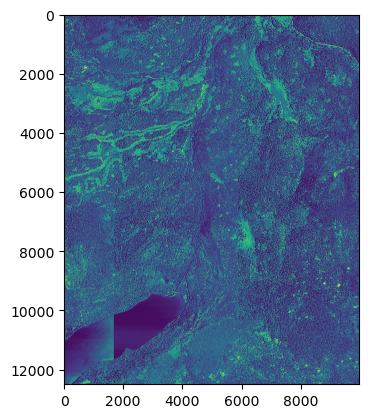

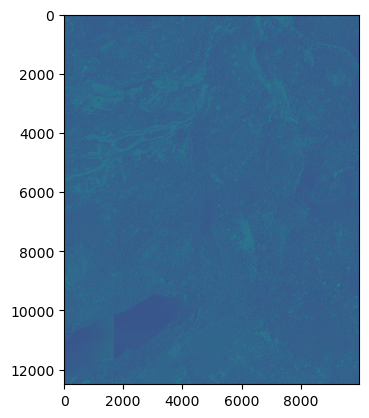

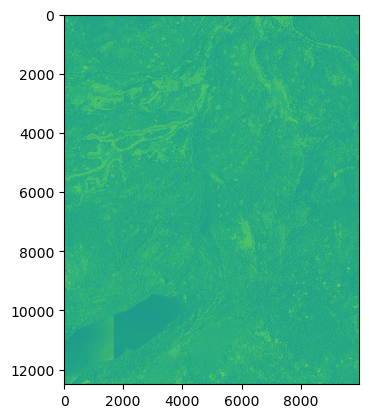

In [93]:
plt.imshow(band)
plt.show()


plt.imshow(band - convolve2d(band, lap_adjacent, boundary="fill")[1:-1, 1:-1])
plt.show()

plt.imshow(band + convolve2d(band, lap_adjacent, boundary="fill")[1:-1, 1:-1])
plt.show()

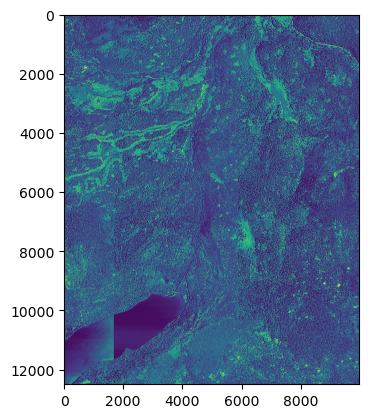

In [85]:
plt.imshow(band)
plt.show()

In [82]:
adj_diff.min(), adj_diff.max()

(np.float64(0.0), np.float64(255.0))

In [74]:
adj_diff.shape

(12502, 9982)

In [ ]:
def process_band(band):
    """
    Perform all band processing. Bands can be processed individually as they are only comparable to bands of the same input.
    """
    pass